# Patient Data Analysis Project

**Tools:** pandas, matplotlib, seaborn  
**Dataset:** `patients_easy.csv` (632 raw patient records, 11 columns)

## Summary of cleaning decisions
- Missing `insurance_provider` values were labeled **Not Provided**, because uninsured patients are already recorded as **Self Pay**.
- The 27 insurance spellings were merged into **8 categories**.
- `gender` was standardized to **Male / Female**.
- **24 exact duplicate rows** were removed (632 to 608 rows).
- **8 patient IDs are shared by two different people.** These rows were kept, because they are different patients.
- Dates were converted to real dates. Two-digit birth years that landed in the future (for example 2074) were moved back 100 years.
- **5 impossible birth dates** (born after registering) were set to missing.
- `state` values were converted to 2-letter codes (50 states, DC and 8 territories = 59).
- `city` and `full_name` were given consistent capitalization. Titles (Mr., Dr.) and suffixes (MD, III) were removed from names.
- Emails were fixed (`,com`, `gmial`, ` at `, titles at the start).
- Phone numbers were reduced to 10 digits, and the text `unknown` became a real missing value.
- Zip codes were made 5 digits (extra digits cut, leading zero restored).

## 1. Load and first look

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [4]:
df = pd.read_csv('data/patients_easy.csv')

In [5]:
df.head()

,patient_id,full_name,gender,date_of_birth,phone,email,city,state,zip_code,insurance_provider,registration_date
0,102,Joshua Hickman,m,"October 06, 1989",4540193802,joshua.hickman@yahoo.com,Khanburgh,PW,05264,NaN,"November 06, 2024"
1,576,Julie Garcia,FEMALE,"October 26, 2025",128-866-5268,"julie_garcia@gmail,com",Lake Kelly,Michigan,44625,Blue Cross,2023-01-28
2,408,Robert Brown,male,1984-05-07,804-661-9639,robert.brown@hotmail.com,South Patrickchester,FM,81793,Blue-Cross,2026-06-30
3,442,Anthony Cruz,male,24-Sep-1981,050-249-7243,"anthony_cruz@gmail,com",North Darryl,Colorado,84963,NaN,02/27/2025
4,224,Brenda Shields,FEMALE,2013-12-27,+11386589026,brenda.shields@gmial.com,PORT CHRISTOPHERBERG,New Mexico,79176,bluecross,03-29-25


In [6]:
df.shape

(632, 11)

In [7]:
df.describe()

,patient_id
count,632.000000
mean,303.028481
std,174.273823
min,1.000000
25%,150.750000
50%,303.500000
75%,455.250000
max,600.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632 entries, 0 to 631
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          632 non-null    int64 
 1   full_name           632 non-null    object
 2   gender              632 non-null    object
 3   date_of_birth       611 non-null    object
 4   phone               498 non-null    object
 5   email               609 non-null    object
 6   city                632 non-null    object
 7   state               632 non-null    object
 8   zip_code            632 non-null    object
 9   insurance_provider  567 non-null    object
 10  registration_date   618 non-null    object
dtypes: int64(1), object(10)
memory usage: 54.4+ KB


In [9]:
df.isnull().sum()

patient_id              0
full_name               0
gender                  0
date_of_birth          21
phone                 134
email                  23
city                    0
state                   0
zip_code                0
insurance_provider     65
registration_date      14
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(24)

## 2. Data cleaning

### 2.1 Insurance provider

In [11]:
df['insurance_provider'] = df['insurance_provider'].fillna('Not Provided')

In [12]:
df['insurance_provider'].isna().sum()

np.int64(0)

In [13]:
df['insurance_provider'].value_counts()

insurance_provider
Not Provided     65
MEDICAID         39
MEDICARE         32
Medicaid         30
unitedhealth     26
medicaid         26
UnitedHealth     26
BLUECROSS        23
UHC              23
AETNA            22
Cigna            22
Medicare         22
Cigna Health     21
Medi-care        21
United Health    20
Self-Pay         20
Aetnaa           20
aetna            20
Aetna            19
Blue-Cross       19
CIGNA            18
cigna            17
Blue Cross       17
BlueCross        16
self pay         15
Aetna Inc.       14
medicare         12
bluecross         7
Name: count, dtype: int64

In [14]:
mapping = {
    'medicaid': 'Medicaid',
    'medicare': 'Medicare', 'medi-care': 'Medicare',
    'unitedhealth': 'UnitedHealth', 'united health': 'UnitedHealth', 'uhc': 'UnitedHealth',
    'bluecross': 'Blue Cross', 'blue-cross': 'Blue Cross', 'blue cross': 'Blue Cross',
    'aetna': 'Aetna', 'aetnaa': 'Aetna', 'aetna inc.': 'Aetna',
    'cigna': 'Cigna', 'cigna health': 'Cigna',
    'self-pay': 'Self Pay', 'self pay': 'Self Pay',
    'not provided': 'Not Provided'
}

df['insurance_provider'] = df['insurance_provider'].str.strip().str.lower().map(mapping)

In [15]:
df['insurance_provider'].isna().sum()

np.int64(0)

In [16]:
df['insurance_provider'].nunique()

8

In [17]:
df['insurance_provider'].value_counts()

insurance_provider
Medicaid        95
Aetna           95
UnitedHealth    95
Medicare        87
Blue Cross      82
Cigna           78
Not Provided    65
Self Pay        35
Name: count, dtype: int64

### 2.2 Duplicates

In [18]:
df = df.sort_values('patient_id').reset_index(drop=True)

In [19]:
df[df['patient_id'].duplicated(keep=False)]

,patient_id,full_name,gender,date_of_birth,phone,email,city,state,zip_code,insurance_provider,registration_date
20,21,Aaron Frost,M,1952-02-08,unknown,"aaronfrost@gmail,com",Angelaborough,MT,87654,Medicare,13-Sep-2023
21,21,Aaron Frost,M,1952-02-08,unknown,"aaronfrost@gmail,com",Angelaborough,MT,87654,Medicare,13-Sep-2023
50,50,Harold Fields,Male,23-Jan-2017,NaN,haroldfields@outlook.com,East David,Ohio,48454-9138,Not Provided,16-Apr-2024
51,50,Harold Fields,Male,23-Jan-2017,NaN,haroldfields@outlook.com,East David,Ohio,48454-9138,Not Provided,16-Apr-2024
72,71,Lisa Cox,Female,1973-09-17,9051518644,lisa_cox@yahoo.com,West Christopher,Texas,19038,Medicaid,2025-05-17
...,...,...,...,...,...,...,...,...,...,...,...
596,567,Michael Hill,MALE,10-22-21,9609454490,michael.hill at yahoo.com,West Ashleymouth,Kentucky,23934,Medicare,23-Mar-2026
597,568,Alan Smith,male,02-15-02,360-914-9851,alan_smith@gmial.com,Whiteview,Kentucky,65372,Cigna,2023-02-26
598,568,Alan Smith,male,02-15-02,360-914-9851,alan_smith@gmial.com,Whiteview,Kentucky,65372,Cigna,2023-02-26
601,571,Jade Dunlap,F,1981-05-11,+15042901935,"jade.dunlap@gmail,com",Shelbyfurt,MP,76874,Not Provided,2024-02-11


In [20]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(608, 11)

In [21]:
df['patient_id'].duplicated().sum()

np.int64(8)

In [22]:
pd.set_option('display.max_rows', None)
df[df['patient_id'].duplicated(keep=False)]

,patient_id,full_name,gender,date_of_birth,phone,email,city,state,zip_code,insurance_provider,registration_date
98,99,April Little,F,07-16-46,unknown,aprillittle@hotmail.com,New Justin,Nebraska,84505,UnitedHealth,"July 27, 2023"
99,99,Christopher Barr,male,1980-09-24,973-348-4344,NaN,Lake Janet,Massachusetts,63389,Aetna,04-Sep-2025
132,132,Tyler Hall,Male,09/07/1979,609-379-6603,tyler_hall@gmial.com,West Karen,AS,08701,Aetna,10-Feb-2026
133,132,Mr. Micheal Evans,male,"March 17, 2016",unknown,mr..micheal.evans@outlook.com,Romerohaven,Missouri,15584,Medicaid,31-Jul-2026
138,137,Brian Hampton,Male,04-07-97,+18361340745,brianhampton@outlook.com,South Michelleville,WI,31557,Aetna,20-Jul-2025
139,137,Monica Nielsen,FEMALE,01/10/2006,unknown,monicanielsen at outlook.com,West Brianborough,Pennsylvania,69501,Aetna,2024-04-04
337,335,Marc Lopez,Male,12-02-70,+14968549822,marclopez@outlook.com,Parkermouth,Maine,48844,Medicare,02-04-25
338,335,Heidi Ferguson,F,04-May-1962,(845) 765-2132,heidi_ferguson@hotmail.com,Port Jacob,MH,73725,Medicare,24-Jul-2025
407,404,Christine Watson,Female,1987-09-26,7107044964,"christinewatson@gmail,com",North Joshuafurt,NM,2971,Not Provided,"May 30, 2023"
408,404,Kathleen Arnold,Female,1980-12-13,124.938.4308,"kathleenarnold@gmail,com",Erinmouth,Alabama,56483,Medicaid,20-May-2026


### 2.3 Gender

In [23]:
df['gender'].value_counts()

gender
male      72
m         68
MALE      66
FEMALE    65
Male      61
M         59
F         58
female    56
Female    53
f         50
Name: count, dtype: int64

In [24]:
mapping2 = {
    'male' : 'Male',
    'm' : 'Male',
    'MALE' : 'Male',
    'Male' : 'Male',
    'M' : 'Male',
    'FEMALE' : 'Female',
    'F' : 'Female',
    'female' : 'Female',
    'Female' : 'Female',
    'f' : 'Female'
}

df['gender'] = df['gender'].str.strip().str.lower().map(mapping2)

In [25]:
df.head()

,patient_id,full_name,gender,date_of_birth,phone,email,city,state,zip_code,insurance_provider,registration_date
0,1,Alexander Hill,Male,1972-08-06,+11960013389,alexander_hill at gmail.com,New Jamesside,Nebraska,29394,Medicaid,01-21-26
1,2,Diana Booth,Female,08/12/1984,unknown,diana.booth@outlook.com,Lindsaymouth,Ohio,16862,Self Pay,09-13-23
2,3,Mr. Juan Calderon,Male,10-Nov-1968,NaN,mr.juancalderon@yahoo.com,West Michael,Texas,35494,Cigna,07/25/2026
3,4,Melinda Jones,Female,02/24/1951,764-835-0305,melinda_jones@hotmail.com,Adamsborough,Oregon,94599,Aetna,14-Apr-2024
4,5,Mary Foster,Female,31-Mar-1986,3884969653,maryfoster@outlook.com,New Trevor,Wisconsin,06676,Blue Cross,04/10/2026


In [26]:
df['gender'].isna().sum()

np.int64(0)

In [27]:
df['gender'].value_counts()

gender
Male      326
Female    282
Name: count, dtype: int64

### 2.4 Dates (date of birth and registration date)

In [28]:
before = df[['date_of_birth', 'registration_date']].isna().sum()

df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], format='mixed', errors='coerce')
df['registration_date'] = pd.to_datetime(df['registration_date'], format='mixed', errors='coerce')

after = df[['date_of_birth', 'registration_date']].isna().sum()
print(before, after)

date_of_birth        21
registration_date    13
dtype: int64 date_of_birth        21
registration_date    13
dtype: int64


In [29]:
today = pd.Timestamp.today()
df[['date_of_birth', 'registration_date']].agg(['min', 'max'])

,date_of_birth,registration_date
min,1930-09-08,2023-01-01
max,2074-12-25,2026-07-31


In [30]:
bad = df[df['date_of_birth'] > today]
print(len(bad))
bad[['patient_id', 'date_of_birth', 'registration_date']]

51


,patient_id,date_of_birth,registration_date
27,28,2074-01-29,2024-05-31
53,54,2069-03-17,2024-07-26
64,65,2065-07-15,2026-06-19
68,69,2074-03-07,2025-01-15
71,72,2051-03-19,2023-09-26
89,90,2070-11-29,2024-01-24
98,99,2046-07-16,2023-07-27
106,106,2072-11-03,2025-08-24
107,107,2044-06-17,2025-12-19
116,116,2074-09-30,2026-01-02


In [31]:
mask = df['date_of_birth'] > pd.Timestamp.today()
df.loc[mask, 'date_of_birth'] -= pd.DateOffset(years=100)

In [32]:
df['date_of_birth'].max()

Timestamp('2026-05-27 00:00:00')

In [33]:
bad2 = df[df['registration_date'] < df['date_of_birth']]
print(len(bad2))
bad2[['patient_id', 'date_of_birth', 'registration_date']]

5


,patient_id,date_of_birth,registration_date
74,75,2026-03-13,2023-06-17
265,263,2026-05-27,2023-03-02
477,472,2025-09-07,2023-06-03
552,545,2026-04-30,2023-07-26
583,576,2025-10-26,2023-01-28


In [34]:
mask2 = df['registration_date'] < df['date_of_birth']
df.loc[mask2, 'date_of_birth'] = pd.NaT

In [35]:
(df['registration_date'] < df['date_of_birth']).sum()

np.int64(0)

In [36]:
df[['date_of_birth', 'registration_date']].agg(['min', 'max'])

,date_of_birth,registration_date
min,1930-09-08,2023-01-01
max,2024-01-25,2026-07-31


In [37]:
df[['date_of_birth', 'registration_date']].isna().sum()

date_of_birth        26
registration_date    13
dtype: int64

### 2.5 State

In [38]:
df['state'].value_counts()

state
New York          13
North Dakota      13
Delaware          12
Alabama           11
Maine             11
Oregon            10
NC                 9
Hawaii             9
Minnesota          9
Vermont            9
Oklahoma           8
MH                 8
KS                 8
Iowa               8
MN                 8
New Mexico         8
Idaho              8
Colorado           8
Wisconsin          8
UT                 8
Texas              8
AS                 8
Michigan           8
Maryland           7
MP                 7
Mississippi        7
Ohio               7
Nebraska           7
NE                 7
WI                 7
Missouri           7
Pennsylvania       7
KY                 7
Kentucky           7
Washington         7
NM                 7
MO                 7
MT                 6
West Virginia      6
WA                 6
DE                 6
Arizona            6
WV                 6
SC                 6
Kansas             6
HI                 6
Louisiana          6
South C

In [39]:
full_to_abbr = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
    'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO',
    'Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH',
    'Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT',
    'Virginia':'VA','Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

df['state'] = df['state'].str.strip().replace(full_to_abbr)

In [40]:
df['state'].nunique()

59

In [41]:
df.head()

,patient_id,full_name,gender,date_of_birth,phone,email,city,state,zip_code,insurance_provider,registration_date
0,1,Alexander Hill,Male,1972-08-06,+11960013389,alexander_hill at gmail.com,New Jamesside,NE,29394,Medicaid,2026-01-21
1,2,Diana Booth,Female,1984-08-12,unknown,diana.booth@outlook.com,Lindsaymouth,OH,16862,Self Pay,2023-09-13
2,3,Mr. Juan Calderon,Male,1968-11-10,NaN,mr.juancalderon@yahoo.com,West Michael,TX,35494,Cigna,2026-07-25
3,4,Melinda Jones,Female,1951-02-24,764-835-0305,melinda_jones@hotmail.com,Adamsborough,OR,94599,Aetna,2024-04-14
4,5,Mary Foster,Female,1986-03-31,3884969653,maryfoster@outlook.com,New Trevor,WI,06676,Blue Cross,2026-04-10


### 2.6 City

In [42]:
(df['city'] != df['city'].str.title()).sum()

np.int64(27)

In [43]:
df['city'].nunique()

590

In [44]:
df['city'] = df['city'].str.strip().str.title()

In [45]:
(df['city'] != df['city'].str.title()).sum()

np.int64(0)

In [46]:
df['city'].nunique()

589

### 2.7 Email

In [47]:
df['email'].head(30)

0       alexander_hill at gmail.com
1           diana.booth@outlook.com
2         mr.juancalderon@yahoo.com
3         melinda_jones@hotmail.com
4            maryfoster@outlook.com
5       christian_moore@outlook.com
6           nathan.cortez@gmail,com
7           david.bradley@gmial.com
8            james_powers@gmail.com
9          taylor.heath@outlook.com
10          john_daniel@outlook.com
11    matthew_fernandez@outlook.com
12         nicholas.logan@gmial.com
13          barry_hensley@yahoo.com
14        michael.evans@outlook.com
15            loganarcher@gmail,com
16          terrywilliams@yahoo.com
17       brittanyanderson@yahoo.com
18      jennifer.santiago@yahoo.com
19        mr._martin_ross@yahoo.com
20             aaronfrost@gmail,com
21              megan.orr@gmial.com
22          diane.beck at gmail.com
23       kathleen.sanchez@gmial.com
24       jessicameadows@outlook.com
25          chris.reyes@outlook.com
26       heather_molina@outlook.com
27         terry_vargas@outl

In [48]:
df['email'] = df['email'].str.replace(',com', '.com')
df['email'].str.contains(',').sum()

0

In [49]:
df['email'] = df['email'].str.replace('gmial', 'gmail')
df['email'].str.contains('gmial').sum()

0

In [50]:
df['email'] = df['email'].str.replace(' at ', '@')
df['email'].str.contains(' at ').sum()

0

In [51]:
df[df['email'].str.contains(r'^(mr|mrs|ms|dr)[._]', na=False)]['email']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17792\2129926236.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['email'].str.contains(r'^(mr|mrs|ms|dr)[._]', na=False)]['email']


2             mr.juancalderon@yahoo.com
19            mr._martin_ross@yahoo.com
33       ms.heatherchavezmd@hotmail.com
103           mr.jonzunigadvm@gmail.com
133       mr..micheal.evans@outlook.com
158          mr..eric.baker@hotmail.com
163    dr..brett.sandoval.iii@yahoo.com
345       mrs._ashley_kim_dds@gmail.com
379       mr..robert.miller@hotmail.com
400       mr..micheal.evans@outlook.com
415         ms..mary.thomas@outlook.com
523     dr..jennifer.hoover@hotmail.com
536      mr._james_williamson@gmail.com
Name: email, dtype: object

In [52]:
df['email'] = df['email'].str.replace(r'^(mr|mrs|ms|dr)[._]+', '', regex=True)

In [53]:
df[df['email'].str.contains(r'^(mr|mrs|ms|dr)[._]', na=False)]['email']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17792\2129926236.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['email'].str.contains(r'^(mr|mrs|ms|dr)[._]', na=False)]['email']


Series([], Name: email, dtype: object)

In [54]:
df['email'].str.contains('@').value_counts()

email
True    586
Name: count, dtype: int64

### 2.8 Phone

In [55]:
 df['phone'].head(30)

0       +11960013389
1            unknown
2                NaN
3       764-835-0305
4         3884969653
5         6978480184
6            unknown
7     (822) 782-4896
8       133-150-9839
9       +17382997376
10      133-387-2624
11    (677) 360-2606
12           unknown
13      990-916-9985
14      991-183-8425
15               NaN
16    (524) 278-6801
17        3315869232
18    (607) 337-5433
19    (294) 019-6556
20           unknown
21        4436995777
22      332-003-7917
23               NaN
24      434.873.4714
25        6587603669
26      373-467-0656
27        7204653755
28               NaN
29               NaN
Name: phone, dtype: object

In [56]:
df['phone'] = df['phone'].replace('unknown', np.nan)

In [57]:
df['phone'].isna().sum()

np.int64(205)

In [58]:
df['phone'] = df['phone'].str.replace(r'\D', '', regex=True)

In [59]:
df['phone'].str.len().value_counts()

phone
10.0    327
11.0     76
Name: count, dtype: int64

In [60]:
mask = df['phone'].str.len() == 11
df.loc[mask, 'phone'] = df.loc[mask, 'phone'].str[1:]

In [61]:
df['phone'].str.len().value_counts()

phone
10.0    403
Name: count, dtype: int64

### 2.9 Zip code

In [62]:
df['zip_code'].str.len().value_counts()

zip_code
5     582
10     20
4       6
Name: count, dtype: int64

In [63]:
df['zip_code'] = df['zip_code'].str[:5]

In [64]:
df['zip_code'].str.len().value_counts()

zip_code
5    602
4      6
Name: count, dtype: int64

In [65]:
df['zip_code'] = df['zip_code'].str.zfill(5)

In [66]:
df['zip_code'].str.len().value_counts()

zip_code
5    608
Name: count, dtype: int64

### 2.10 Full name

In [67]:
df[df['full_name'].str.contains(r'^(Mr|Mrs|Ms|Dr)\.?\s', na=False)]['full_name']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17792\3838341986.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['full_name'].str.contains(r'^(Mr|Mrs|Ms|Dr)\.?\s', na=False)]['full_name']


2           Mr. Juan Calderon
19            Mr. Martin Ross
33      Ms. Heather Chavez MD
87          Mr. Jerry Frazier
103        Mr. Jon Zuniga DVM
133         Mr. Micheal Evans
163    Dr. Brett Sandoval III
345       Mrs. Ashley Kim DDS
379         Mr. Robert Miller
400         Mr. Micheal Evans
415           Ms. Mary Thomas
523       Dr. Jennifer Hoover
Name: full_name, dtype: object

In [68]:
df['full_name'] = df['full_name'].str.replace(r'^(Mr|Mrs|Ms|Dr)\.?\s+', '', regex=True)

In [69]:
df[df['full_name'].str.contains(r'^(Mr|Mrs|Ms|Dr)\.?\s', na=False)]['full_name']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17792\3838341986.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['full_name'].str.contains(r'^(Mr|Mrs|Ms|Dr)\.?\s', na=False)]['full_name']


Series([], Name: full_name, dtype: object)

In [70]:
df['full_name'] = df['full_name'].str.replace(r'\s+(MD|DVM|DDS|PhD|Jr\.?|Sr\.?|II|III|IV)$', '', regex=True)

In [71]:
df[df['full_name'].str.contains(r'\s(MD|DVM|DDS|PhD|Jr\.?|Sr\.?|II|III|IV)$', na=False)]['full_name']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17792\2038479807.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['full_name'].str.contains(r'\s(MD|DVM|DDS|PhD|Jr\.?|Sr\.?|II|III|IV)$', na=False)]['full_name']


Series([], Name: full_name, dtype: object)

In [72]:
df['full_name'].str.strip().ne(df['full_name']).sum()

np.int64(16)

In [73]:
df['full_name'].sample(15)

276    Jennifer Thompson
562            Laura Lin
267      Theodore Jordan
429       Ashley Herrera
60          Jacob Farmer
381        Linda Spencer
300        Karen Alvarez
424         Robyn Sutton
560       Phillip Obrien
13         Barry Hensley
187        George Barron
157         JAMES DECKER
98          April Little
323       robert everett
61       Charles Schultz
Name: full_name, dtype: object

In [74]:
df['full_name'] = df['full_name'].str.strip().str.title()

In [75]:
df['full_name'].str.strip().ne(df['full_name']).sum()

np.int64(0)

### 2.11 Final checks and save

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.shape

(608, 11)

In [78]:
df.columns = df.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')

In [79]:
df.to_csv('data/patients_clean.csv', index=False)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Patient_Id          608 non-null    int64         
 1   Full_Name           608 non-null    object        
 2   Gender              608 non-null    object        
 3   Date_Of_Birth       582 non-null    datetime64[ns]
 4   Phone               403 non-null    object        
 5   Email               586 non-null    object        
 6   City                608 non-null    object        
 7   State               608 non-null    object        
 8   Zip_Code            608 non-null    object        
 9   Insurance_Provider  608 non-null    object        
 10  Registration_Date   595 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(8)
memory usage: 52.4+ KB


## 3. Data visualization

The cleaned file is loaded again as `df2` and used for all charts.

In [81]:
df2 = pd.read_csv('data/patients_clean.csv',
                  parse_dates=['Date_Of_Birth', 'Registration_Date'],
                  dtype={'Zip_Code': str, 'Phone': str})

In [82]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Patient_Id          608 non-null    int64         
 1   Full_Name           608 non-null    object        
 2   Gender              608 non-null    object        
 3   Date_Of_Birth       582 non-null    datetime64[ns]
 4   Phone               403 non-null    object        
 5   Email               586 non-null    object        
 6   City                608 non-null    object        
 7   State               608 non-null    object        
 8   Zip_Code            608 non-null    object        
 9   Insurance_Provider  608 non-null    object        
 10  Registration_Date   595 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(8)
memory usage: 52.4+ KB


### Age column

In [83]:
df2['Age'] = ((pd.Timestamp.today() - df2['Date_Of_Birth']).dt.days / 365.25).round()

In [84]:
df2['Age'].describe()

count    582.00000
mean      45.38488
std       18.68425
min        3.00000
25%       32.00000
50%       46.00000
75%       57.00000
max       96.00000
Name: Age, dtype: float64

### Chart 1: Patient age distribution

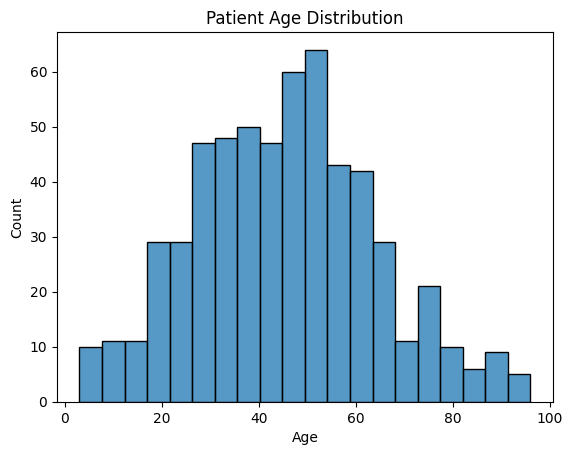

In [85]:
sns.histplot(data=df2, x='Age', bins=20)
plt.title('Patient Age Distribution')
plt.show()

### Chart 2: Patients by insurance provider

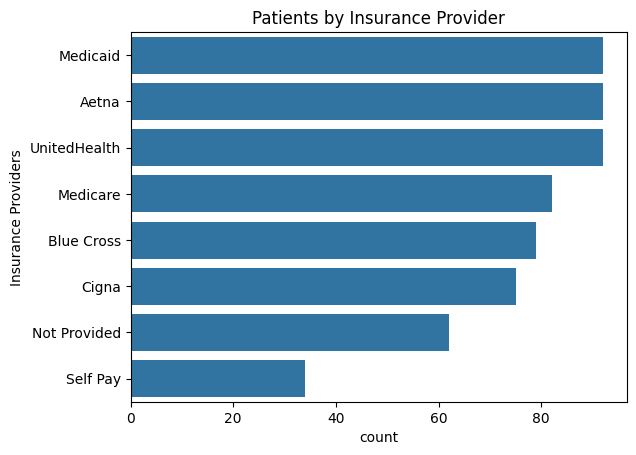

In [86]:
sns.countplot(data=df2, y='Insurance_Provider', order=df2['Insurance_Provider'].value_counts().index)
plt.title('Patients by Insurance Provider')
plt.ylabel('Insurance Providers')
plt.show()

### Chart 3: Patients by gender

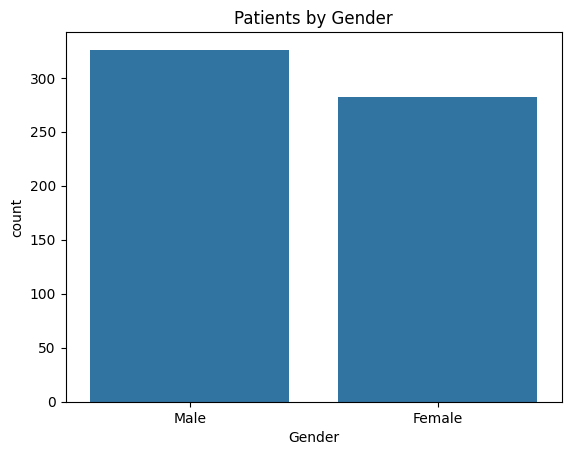

In [87]:
sns.countplot(data=df2, x='Gender')
plt.title('Patients by Gender')
plt.show()

### Chart 4: Registrations per month

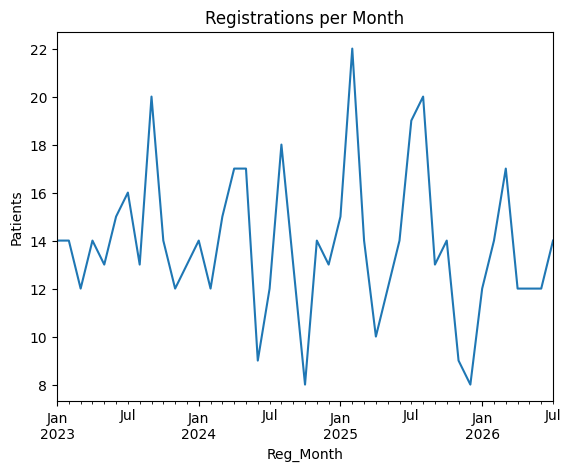

In [88]:
df2['Reg_Month'] = df2['Registration_Date'].dt.to_period('M')
monthly = df2.groupby('Reg_Month').size()
monthly.plot()
plt.title('Registrations per Month')
plt.ylabel('Patients')
plt.show()

### Chart 5: Top 10 states by patients

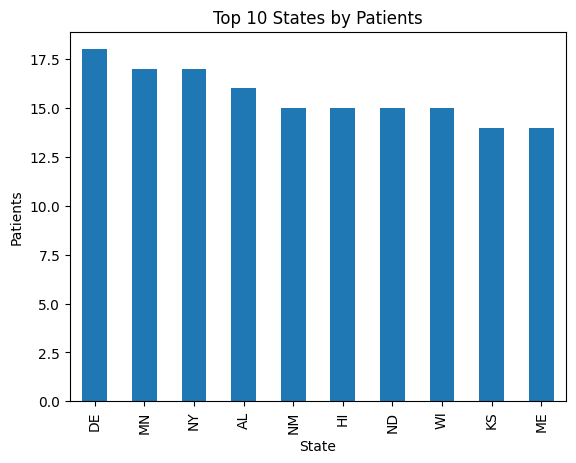

In [89]:
top_states = df2['State'].value_counts().head(10)
top_states.plot(kind='bar')
plt.title('Top 10 States by Patients')
plt.ylabel('Patients')
plt.show()

### Chart 6: Age by insurance provider

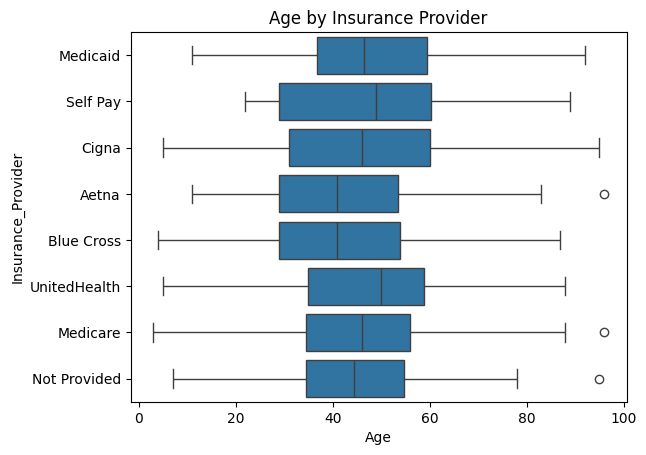

In [90]:
sns.boxplot(data=df2, x='Age', y='Insurance_Provider')
plt.title('Age by Insurance Provider')
plt.show()

### Chart 7: Gender by insurance provider

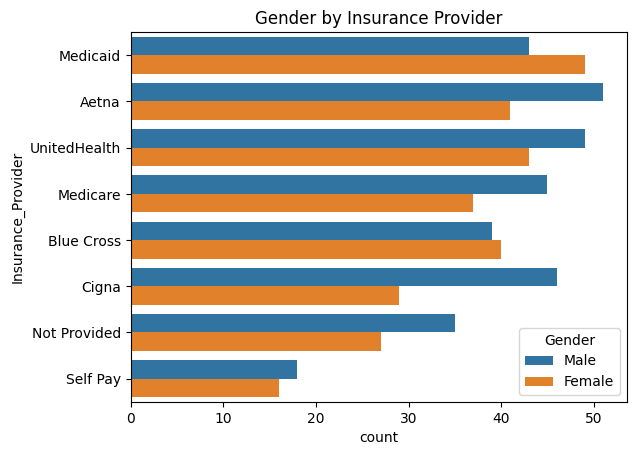

In [91]:
sns.countplot(data=df2, y='Insurance_Provider', hue='Gender', order=df2['Insurance_Provider'].value_counts().index)
plt.title('Gender by Insurance Provider')
plt.show()

### Chart 8: Patients by age group

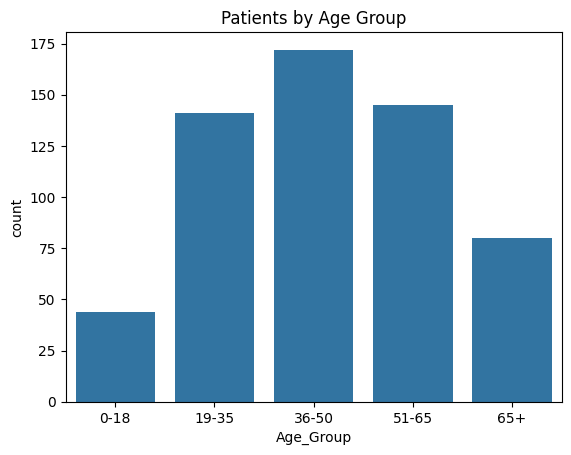

In [92]:
df2['Age_Group'] = pd.cut(df2['Age'], bins=[0, 18, 35, 50, 65, 100],
                          labels=['0-18', '19-35', '36-50', '51-65', '65+'])
sns.countplot(data=df2, x='Age_Group')
plt.title('Patients by Age Group')
plt.show()

## 4. Key findings

1. **Patients are mostly middle-aged.** The average age is about 45 (median 46), and the ages run from 3 to 96.
2. **The largest age group is 36-50.** About 80% of patients with a known age are between 19 and 65.
3. **Patients are spread fairly evenly across insurers.** Medicaid, Aetna and UnitedHealth are the largest groups (about 92 patients each). Self Pay is the smallest (about 34).
4. **About 10% of patients have no insurance information recorded** ("Not Provided").
5. **The population is slightly more male than female** (326 vs. 282, about 54% vs. 46%).
6. **Monthly registrations stay steady at about 14 patients**, with random ups and downs between about 8 and 22 and no long-term trend (January 2023 to July 2026).
7. **Patients come from all over the country.** The top 10 states each have 14 to 18 patients, and no state has more than about 3% of the total.
8. **Age and gender do not differ much between insurers.** Median ages range from about 41 to 50. Most insurers have slightly more male patients, but the groups are small, so the differences may be due to chance.

## 5. Limitations and assumptions
- Dates like `09/07/1979` were read as month first.
- Two-digit birth years that landed in the future were moved back 100 years. A year like `02` could also have meant 1902, which cannot be told apart.
- Zip codes with 4 digits were assumed to have lost a leading zero.
- Missing insurance was labeled "Not Provided" and not "Self Pay", because it is unknown whether those patients are uninsured.
- Ages do not follow real-world patterns (for example, Medicare patients as young as 3), so this looks like synthetic data, and the findings describe this dataset only.
- Phone (205), email (22), birth date (26) and registration date (13) still have missing values, because the real values are unknown.